In [13]:
import numpy as np
import pandas as pd
import re

In [14]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [15]:
df = pd.read_csv('gurgaon_properties_cleaned.csv')

In [16]:
df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,breez global hill view,sohna road,0.3,5124.0,585.0,Carpet area: 585.41 (54.39 sq.m.),2,2,1,not available,11.0,North,0 to 1 Year Old,"['Huda City Centre', 'Omaxe City Centre', 'Ninex City Mart', 'Vaels Ravindra Bharathi Global School', 'Anjali nursery', 'Polaris Hospital', 'Axis Bank', 'Triangular Park', 'Flow Sports Life Badminton Club', 'Basai Dhankot Railway Station', 'Cars24', 'Radisson Hotel Gurugram', ""McDonald's"", 'Petrol Pump', 'Indian Post Office']",NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Lift(s)', 'Centrally Air Conditioned', 'High Ceiling Height', 'Maintenance Staff', 'No open drainage around', 'Recently Renovated', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Low Density Society', 'Shopping Centre', 'Waste Disposal']"


#  areaWithType

In [17]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
1247,0.71,1310.0,Super Built up area 1310(121.7 sq.m.)Built Up area: 1100 sq.ft. (102.19 sq.m.)Carpet area: 1000 sq.ft. (92.9 sq.m.)
2625,0.60,900.0,Super Built up area 900(83.61 sq.m.)
2745,2.45,3000.0,Super Built up area 3000(278.71 sq.m.)Built Up area: 2900 sq.ft. (269.42 sq.m.)Carpet area: 2800 sq.ft. (260.13 sq.m.)
53,1.25,1600.0,Super Built up area 2390(222.04 sq.m.)Carpet area: 1600 sq.ft. (148.64 sq.m.)
1243,2.25,900.0,Plot area 100(83.61 sq.m.)


In [18]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [19]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [20]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [21]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [22]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1635,1.93,flat,2390.0,Super Built up area 2408(223.71 sq.m.)Built Up area: 2400 sq.ft. (222.97 sq.m.)Carpet area: 2390 sq.ft. (222.04 sq.m.),2408.0,2400.0,2390.0
2400,1.35,flat,1880.0,Super Built up area 1880(174.66 sq.m.)Carpet area: 1128 sq.ft. (104.79 sq.m.),1880.0,NaN,1128.0
3009,1.35,flat,2692.0,Carpet area: 2692 (250.09 sq.m.),NaN,NaN,2692.0
2932,1.44,flat,1578.0,Super Built up area 1578(146.6 sq.m.)Carpet area: 1200 sq.ft. (111.48 sq.m.),1578.0,NaN,1200.0
2897,5.00,flat,3000.0,Super Built up area 3246(301.56 sq.m.)Built Up area: 3245 sq.ft. (301.47 sq.m.)Carpet area: 3000 sq.ft. (278.71 sq.m.),3246.0,3245.0,3000.0


In [23]:
df.duplicated().sum()

np.int64(122)

In [24]:
df = df.drop_duplicates()


In [25]:

df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(531, 7)

In [26]:

df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2,3.65,house,3450.0,Plot area 3450(320.52 sq.m.),NaN,NaN,NaN
3,7.10,house,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 239 sq.yards (199.83 sq.m.)Carpet area: 238 sq.yards (199 sq.m.),NaN,239.0,238.0
4,13.50,house,3618.0,Plot area 402(336.12 sq.m.),NaN,NaN,NaN
5,10.56,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN
6,2.45,house,3159.0,Plot area 60(50.17 sq.m.)Built Up area: 540 sq.yards (451.51 sq.m.)Carpet area: 351 sq.yards (293.48 sq.m.),NaN,540.0,351.0


In [27]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,17
price_per_sqft,17
area,17
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [28]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [29]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2,3.65,house,3450.0,Plot area 3450(320.52 sq.m.),NaN,NaN,NaN
4,13.50,house,3618.0,Plot area 402(336.12 sq.m.),NaN,NaN,NaN
5,10.56,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN
7,10.75,house,3600.0,Plot area 400(334.45 sq.m.),NaN,NaN,NaN
17,5.50,house,2385.0,Plot area 265(221.57 sq.m.),NaN,NaN,NaN


In [30]:

all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [31]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [32]:

all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

In [33]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2,3.65,house,3450.0,Plot area 3450(320.52 sq.m.),NaN,3450.00,NaN
4,13.50,house,3618.0,Plot area 402(336.12 sq.m.),NaN,402.00,NaN
5,10.56,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.00,NaN
7,10.75,house,3600.0,Plot area 400(334.45 sq.m.),NaN,400.00,NaN
17,5.50,house,2385.0,Plot area 265(221.57 sq.m.),NaN,265.00,NaN
25,3.51,house,2844.0,Plot area 316(264.22 sq.m.),NaN,316.00,NaN
41,0.85,house,900.0,Plot area 900(83.61 sq.m.),NaN,900.00,NaN
42,6.75,house,2115.0,Plot area 235(196.49 sq.m.),NaN,235.00,NaN
44,6.50,house,2332.0,Plot area 299(250 sq.m.),NaN,299.00,NaN
47,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,200.00,NaN


In [34]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [35]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [36]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2,3.65,house,3450.0,Plot area 3450(320.52 sq.m.),NaN,3450.00,NaN
4,13.50,house,3618.0,Plot area 402(336.12 sq.m.),NaN,3618.00,NaN
5,10.56,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
7,10.75,house,3600.0,Plot area 400(334.45 sq.m.),NaN,3600.00,NaN
17,5.50,house,2385.0,Plot area 265(221.57 sq.m.),NaN,2385.00,NaN
25,3.51,house,2844.0,Plot area 316(264.22 sq.m.),NaN,2844.00,NaN
41,0.85,house,900.0,Plot area 900(83.61 sq.m.),NaN,900.00,NaN
42,6.75,house,2115.0,Plot area 235(196.49 sq.m.),NaN,2115.00,NaN
44,6.50,house,2332.0,Plot area 299(250 sq.m.),NaN,299.00,NaN
47,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,1800.00,NaN


In [37]:
# update the original dataframe
df.update(all_nan_df)

In [38]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,17
price_per_sqft,17
area,17
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [39]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
0,flat,breez global hill view,sohna road,0.30,5124.0,585.0,Carpet area: 585.41 (54.39 sq.m.),2,2,1,not available,11.0,North,0 to 1 Year Old,"['Huda City Centre', 'Omaxe City Centre', 'Ninex City Mart', 'Vaels Ravindra Bharathi Global School', 'Anjali nursery', 'Polaris Hospital', 'Axis Bank', 'Triangular Park', 'Flow Sports Life Badminton Club', 'Basai Dhankot Railway Station', 'Cars24', 'Radisson Hotel Gurugram', ""McDonald's"", 'Petrol Pump', 'Indian Post Office']",NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Lift(s)', 'Centrally Air Conditioned', 'High Ceiling Height', 'Maintenance Staff', 'No open drainage around', 'Recently Renovated', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Low Density Society', 'Shopping Centre', 'Waste Disposal']",NaN,NaN,585.448521
1,flat,aipl club residences,sector 70a,0.95,10215.0,930.0,Built Up area: 930 (86.4 sq.m.)Carpet area: 730 sq.ft. (67.82 sq.m.),2,2,1,not available,11.0,North-East,0 to 1 Year Old,"['Airia Mall', 'Golf Corse Ext. Rd', 'National Highway-48', 'Indus World School', 'Gurugram University', 'Ananta Hospital', 'Indira Gandhi International Airport', 'DLF Corporate Greens', 'IMT Manesar', 'Hyatt Regency Gurgaon', 'SkyJumper Trampoline Park']","['11 Wardrobe', '1 Fan', '1 Exhaust Fan', '1 Geyser', '1 Light', '3 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Club house / Community Center', 'Water softening plant']",NaN,930.0,730.000000
2,house,ansals florence villa,sector 57,3.65,10579.0,3450.0,Plot area 3450(320.52 sq.m.),6,6,2,"pooja room,study room,servant room,store room",3.0,North-West,5 to 10 Year Old,"['Sector metro station', 'Sector metro station', 'Sector 54 chowk metro station', 'Radhakrishna Shani Mandir', 'Sanatan Dharm Mandir', 'Icici bank ATM', 'State bank ATM', 'Icici bank ATM', 'Citi bank ATM', 'Indusind bank ATM', 'Anand Hospital Gurgaon', 'Kriti Hospital', 'Surgicare Hospital Gurgaon', 'pracksht hospital', 'Arunodaya Deseret Eye Hospital', 'Vatsalya Clinic', 'HUDA Office Complex', 'Medisca', 'Apollo Pharmacy', 'Unitech', 'Heera Fuel Station', 'HCG CNG Station', 'Hdfc bank and atm', 'Hdfc bank', 'Kotak mahindra bank', 'Indusind bank', 'State bank of india', 'Axis bank', 'Icici bank', 'Hdfc bank', 'Hdfc bank & atm', '222', 'Pizza Hut', 'Wat-a-Burger', 'Burger Singh', 'Bikanerwala', 'Naivedyam Restaurant', 'Madison and Pike', 'IILM', 'Iilm University', 'Gurugram University', 'Sushant College of Arts & Architecture', 'Ansal Institute of Technology', 'Amity Global School', 'Kamla International', 'Suncity School', 'St. Angels Sr']","['1 Water Purifier', '1 Fan', '1 Fridge', '1 Exhaust Fan', '1 Dining Table', '1 Geyser', '1 Stove', '1 Light', '1 AC', '1 TV', '1 Modular Kitchen', '1 Chimney', '1 Curtains', '1 Bed', '1 Wardrobe', '1 Sofa', '1 Washing Machine', '1 Microwave']","['Water purifier', 'Centrally Air Conditioned', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Par

# additionalRoom

In [40]:
df['additionalRoom'].value_counts()

,count
additionalRoom,
not available,1190
servant room,687
study room,243
others,219
pooja room,164
store room,97
"study room,servant room",97
"pooja room,servant room",82
"pooja room,study room,servant room,store room",72


In [41]:
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col, na=False).astype(int)


In [42]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
2856,not available,0,0,0,0,0
2545,servant room,0,1,0,0,0
2673,not available,0,0,0,0,0
1616,"pooja room,store room",0,0,1,1,0
1908,not available,0,0,0,0,0


In [43]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,breez global hill view,sohna road,0.30,5124.0,585.0,Carpet area: 585.41 (54.39 sq.m.),2,2,1,not available,11.0,North,0 to 1 Year Old,"['Huda City Centre', 'Omaxe City Centre', 'Ninex City Mart', 'Vaels Ravindra Bharathi Global School', 'Anjali nursery', 'Polaris Hospital', 'Axis Bank', 'Triangular Park', 'Flow Sports Life Badminton Club', 'Basai Dhankot Railway Station', 'Cars24', 'Radisson Hotel Gurugram', ""McDonald's"", 'Petrol Pump', 'Indian Post Office']",NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Lift(s)', 'Centrally Air Conditioned', 'High Ceiling Height', 'Maintenance Staff', 'No open drainage around', 'Recently Renovated', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Low Density Society', 'Shopping Centre', 'Waste Disposal']",NaN,NaN,585.448521,0,0,0,0,0
1,flat,aipl club residences,sector 70a,0.95,10215.0,930.0,Built Up area: 930 (86.4 sq.m.)Carpet area: 730 sq.ft. (67.82 sq.m.),2,2,1,not available,11.0,North-East,0 to 1 Year Old,"['Airia Mall', 'Golf Corse Ext. Rd', 'National Highway-48', 'Indus World School', 'Gurugram University', 'Ananta Hospital', 'Indira Gandhi International Airport', 'DLF Corporate Greens', 'IMT Manesar', 'Hyatt Regency Gurgaon', 'SkyJumper Trampoline Park']","['11 Wardrobe', '1 Fan', '1 Exhaust Fan', '1 Geyser', '1 Light', '3 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Club house / Community Center', 'Water softening plant']",NaN,930.0,730.000000,0,0,0,0,0
2,house,ansals florence villa,sector 57,3.65,10579.0,3450.0,Plot area 3450(320.52 sq.m.),6,6,2,"pooja room,study room,servant room,store room",3.0,North-West,5 to 10 Year Old,"['Sector metro station', 'Sector metro station', 'Sector 54 chowk metro station', 'Radhakrishna Shani Mandir', 'Sanatan Dharm Mandir', 'Icici bank ATM', 'State bank ATM', 'Icici bank ATM', 'Citi bank ATM', 'Indusind bank ATM', 'Anand Hospital Gurgaon', 'Kriti Hospital', 'Surgicare Hospital Gurgaon', 'pracksht hospital', 'Arunodaya Deseret Eye Hospital', 'Vatsalya Clinic', 'HUDA Office Complex', 'Medisca', 'Apollo Pharmacy', 'Unitech', 'Heera Fuel Station', 'HCG CNG Station', 'Hdfc bank and atm', 'Hdfc bank', 'Kotak mahindra bank', 'Indusind bank', 'State bank of india', 'Axis bank', 'Icici bank', 'Hdfc bank', 'Hdfc bank & atm', '222', 'Pizza Hut', 'Wat-a-Burger', 'Burger Singh', 'Bikanerwala', 'Naivedyam Restaurant', 'Madison and Pike', 'IILM', 'Iilm University', 'Gurugram University', 'Sushant College of Arts & Architecture', 'Ansal Institute of Technology', 'Amity Global School', 'Kamla International', 'Suncity School', 'St. Angels Sr']","['1 Water Purifier', '1 Fan', '1 Fridge', '1 Exhaust Fan', '1 Dining Table', '1 Geyser', '1 Stove', '1 Light', '1 AC', '1 TV', '1 Modular Kitchen', '1 Chimney', '1 Curtains', '1 Bed', '1 Wardrobe', '1 Sofa', '1 Washing Machine', '1 Microwave']","['Water purifier', 'Centrally Air Conditioned', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Pipe

# agePossession

In [44]:
df['agePossession'].value_counts()

,count
agePossession,
1 to 5 Year Old,1646
5 to 10 Year Old,562
0 to 1 Year Old,503
undefined,307
10+ Year Old,303
Under Construction,88
Within 6 months,67
Within 3 months,24
Dec-23,20


In [45]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [46]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [47]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1646
New Property,594
Moderately Old,562
Undefined,448
Old Property,303
Under Construction,127


In [48]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,breez global hill view,sohna road,0.30,5124.0,585.0,Carpet area: 585.41 (54.39 sq.m.),2,2,1,not available,11.0,North,New Property,"['Huda City Centre', 'Omaxe City Centre', 'Ninex City Mart', 'Vaels Ravindra Bharathi Global School', 'Anjali nursery', 'Polaris Hospital', 'Axis Bank', 'Triangular Park', 'Flow Sports Life Badminton Club', 'Basai Dhankot Railway Station', 'Cars24', 'Radisson Hotel Gurugram', ""McDonald's"", 'Petrol Pump', 'Indian Post Office']",NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Lift(s)', 'Centrally Air Conditioned', 'High Ceiling Height', 'Maintenance Staff', 'No open drainage around', 'Recently Renovated', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Low Density Society', 'Shopping Centre', 'Waste Disposal']",NaN,NaN,585.448521,0,0,0,0,0
1,flat,aipl club residences,sector 70a,0.95,10215.0,930.0,Built Up area: 930 (86.4 sq.m.)Carpet area: 730 sq.ft. (67.82 sq.m.),2,2,1,not available,11.0,North-East,New Property,"['Airia Mall', 'Golf Corse Ext. Rd', 'National Highway-48', 'Indus World School', 'Gurugram University', 'Ananta Hospital', 'Indira Gandhi International Airport', 'DLF Corporate Greens', 'IMT Manesar', 'Hyatt Regency Gurgaon', 'SkyJumper Trampoline Park']","['11 Wardrobe', '1 Fan', '1 Exhaust Fan', '1 Geyser', '1 Light', '3 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Club house / Community Center', 'Water softening plant']",NaN,930.0,730.000000,0,0,0,0,0
2,house,ansals florence villa,sector 57,3.65,10579.0,3450.0,Plot area 3450(320.52 sq.m.),6,6,2,"pooja room,study room,servant room,store room",3.0,North-West,Moderately Old,"['Sector metro station', 'Sector metro station', 'Sector 54 chowk metro station', 'Radhakrishna Shani Mandir', 'Sanatan Dharm Mandir', 'Icici bank ATM', 'State bank ATM', 'Icici bank ATM', 'Citi bank ATM', 'Indusind bank ATM', 'Anand Hospital Gurgaon', 'Kriti Hospital', 'Surgicare Hospital Gurgaon', 'pracksht hospital', 'Arunodaya Deseret Eye Hospital', 'Vatsalya Clinic', 'HUDA Office Complex', 'Medisca', 'Apollo Pharmacy', 'Unitech', 'Heera Fuel Station', 'HCG CNG Station', 'Hdfc bank and atm', 'Hdfc bank', 'Kotak mahindra bank', 'Indusind bank', 'State bank of india', 'Axis bank', 'Icici bank', 'Hdfc bank', 'Hdfc bank & atm', '222', 'Pizza Hut', 'Wat-a-Burger', 'Burger Singh', 'Bikanerwala', 'Naivedyam Restaurant', 'Madison and Pike', 'IILM', 'Iilm University', 'Gurugram University', 'Sushant College of Arts & Architecture', 'Ansal Institute of Technology', 'Amity Global School', 'Kamla International', 'Suncity School', 'St. Angels Sr']","['1 Water Purifier', '1 Fan', '1 Fridge', '1 Exhaust Fan', '1 Dining Table', '1 Geyser', '1 Stove', '1 Light', '1 AC', '1 TV', '1 Modular Kitchen', '1 Chimney', '1 Curtains', '1 Bed', '1 Wardrobe', '1 Sofa', '1 Washing Machine', '1 Microwave']","['Water purifier', 'Centrally Air Conditioned', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 

# furnishDetails

In [49]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
232,"['6 Fan', '5 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Lift(s)', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']"
3651,[],"['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
1947,NaN,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
676,"['1 Water Purifier', '5 Fan', '1 Exhaust Fan', '3 Geyser', '1 Stove', '12 Light', '4 AC', '1 Chimney', '1 Modular Kitchen', '1 TV', '2 Wardrobe', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Washing Machine']",NaN
448,NaN,"['Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Park', 'Shopping Centre', 'Rain Water Harvesting']"


In [50]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [51]:
furnishings_df.shape

(3680, 19)

In [52]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

<ipython-input-52-e4dadedf8e21>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [53]:
furnishings_df.sample(5)

,Light,Curtains,Geyser,Fan,Washing Machine,Modular Kitchen,AC,Fridge,Chimney,Stove,Exhaust Fan,TV,Bed,Wardrobe,Sofa,Water Purifier,Dining Table,Microwave
672,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2789,0,0,3,6,0,0,3,0,3,0,1,0,0,6,0,0,0,0
729,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
833,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
3209,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [54]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [55]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [56]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

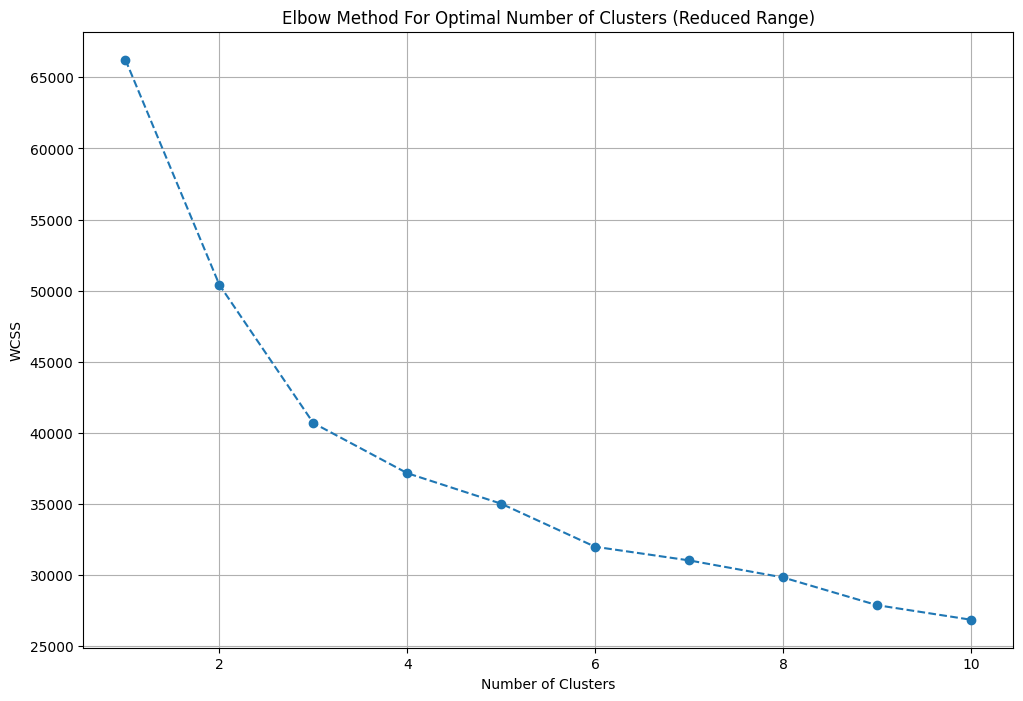

In [57]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [58]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [59]:
df = df.iloc[:,:-18]

In [60]:
df['furnishing_type'] = cluster_assignments

In [62]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0-> Unfurnished
# 1-> semifurnished
# 2-> furnished

,furnishDetails,furnishing_type
571,"['3 Wardrobe', '5 Fan', '1 Exhaust Fan', '4 Geyser', '1 Stove', '5 Light', '5 AC', '1 Chimney', '1 Modular Kitchen', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']",2
949,"['1 Water Purifier', '9 Fan', '1 Fridge', '1 Exhaust Fan', '9 Geyser', '20 Light', '9 AC', '1 Modular Kitchen', '9 TV', '9 Wardrobe', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Sofa', 'No Stove', 'No Washing Machine']",0
1243,"['2 Wardrobe', '7 Fan', '1 Exhaust Fan', '7 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",1
1954,"['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",1
3423,"['6 Wardrobe', '1 Fridge', '8 Fan', '1 Exhaust Fan', '1 Microwave', '1 Stove', '24 Light', '1 Chimney', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']",2


# features

In [63]:
df[['society','features']].sample(5)

,society,features
362,sare homes,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Water purifier', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"
3278,independent,"['Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Rain Water Harvesting']"
3000,emaar mgf palm terraces,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Low Density Society', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"
332,m3m woodshire,"['Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Park', 'Visitor Parking', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']"
3560,bestech park view ananda,"['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'No open drainage around', 'Piped-gas', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"


In [64]:
df['features'].isnull().sum()

np.int64(599)

In [65]:
import pandas as pd
app_df = pd.read_csv('/content/apartments-excel-cleaned.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [66]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [67]:
temp_df = df[df['features'].isnull()]

In [68]:
temp_df.shape

(599, 26)

In [69]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [70]:
df.loc[temp_df.index,'features'] = x.values

In [71]:
df['features'].isnull().sum()

np.int64(457)

In [72]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [75]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [76]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
3513,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
130,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
847,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0
1039,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2954,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [78]:
features_binary_df.shape

(3680, 130)

In [79]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

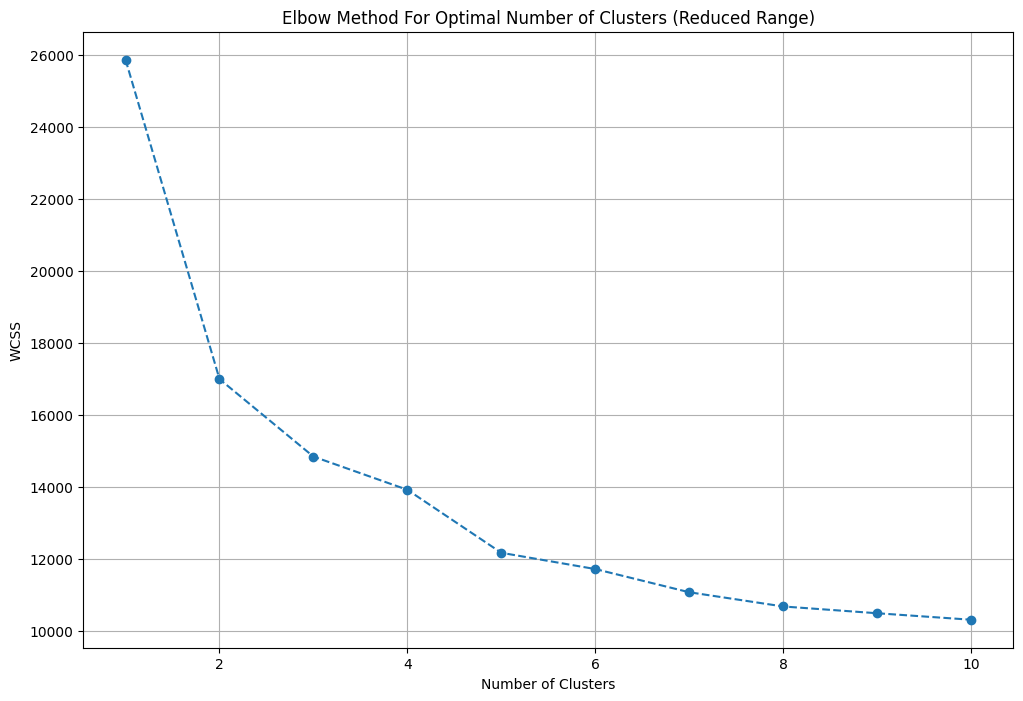

In [80]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [81]:
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [82]:
df['luxury_score'] = luxury_score

In [83]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,flat,breez global hill view,sohna road,0.30,5124.0,585.0,Carpet area: 585.41 (54.39 sq.m.),2,2,1,not available,11.0,North,New Property,"['Huda City Centre', 'Omaxe City Centre', 'Ninex City Mart', 'Vaels Ravindra Bharathi Global School', 'Anjali nursery', 'Polaris Hospital', 'Axis Bank', 'Triangular Park', 'Flow Sports Life Badminton Club', 'Basai Dhankot Railway Station', 'Cars24', 'Radisson Hotel Gurugram', ""McDonald's"", 'Petrol Pump', 'Indian Post Office']",NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Lift(s)', 'Centrally Air Conditioned', 'High Ceiling Height', 'Maintenance Staff', 'No open drainage around', 'Recently Renovated', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Low Density Society', 'Shopping Centre', 'Waste Disposal']",NaN,NaN,585.448521,0,0,0,0,0,1,"[Security / Fire Alarm, Feng Shui / Vaastu Compliant, Lift(s), Centrally Air Conditioned, High Ceiling Height, Maintenance Staff, No open drainage around, Recently Renovated, Park, Security Personnel, Natural Light, Internet/wi-fi connectivity, Airy Rooms, Low Density Society, Shopping Centre, Waste Disposal]",91.0
1,flat,aipl club residences,sector 70a,0.95,10215.0,930.0,Built Up area: 930 (86.4 sq.m.)Carpet area: 730 sq.ft. (67.82 sq.m.),2,2,1,not available,11.0,North-East,New Property,"['Airia Mall', 'Golf Corse Ext. Rd', 'National Highway-48', 'Indus World School', 'Gurugram University', 'Ananta Hospital', 'Indira Gandhi International Airport', 'DLF Corporate Greens', 'IMT Manesar', 'Hyatt Regency Gurgaon', 'SkyJumper Trampoline Park']","['11 Wardrobe', '1 Fan', '1 Exhaust Fan', '1 Geyser', '1 Light', '3 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Club house / Community Center', 'Water softening plant']",NaN,930.0,730.000000,0,0,0,0,0,2,"[Security / Fire Alarm, Feng Shui / Vaastu Compliant, Intercom Facility, Lift(s), High Ceiling Height, Maintenance Staff, Water Storage, No open drainage around, Bank Attached Property, Piped-gas, Visitor Parking, Swimming Pool, Park, Security Personnel, Internet/wi-fi connectivity, Low Density Society, Shopping Centre, Fitness Centre / GYM, Waste Disposal, Club house / Community Center, Water softening plant]",103.0
2,house,ansals florence villa,sector 57,3.65,10579.0,3450.0,Plot area 3450(320.52 sq.m.),6,6,2,"pooja room,study room,servant room,store room",3.0,North-West,Moderately Old,"['Sector metro station', 'Sector metro station', 'Sector 54 chowk metro station', 'Radhakrishna Shani Mandir', 'Sanatan Dharm Mandir', 'Icici bank ATM', 'State bank ATM', 'Icici bank ATM', 'Citi bank ATM', 'Indusind bank ATM', 'Anand Hospital Gurgaon', 'Kriti Hospital', 'Surgicare Hospital Gurgaon', 'pracksht hospital', 'Arunodaya Deseret Eye Hospital', 'Vatsalya Clinic', 'HUDA Office Complex', 'Medisca', 'Apollo Pharmacy', 'Unitech', 'Heera Fuel Station', 'HCG CNG Station', 'Hdfc bank and atm', 'Hdfc bank', 'Kotak mahindra bank', 'Indusind bank', 'State bank of india', 'Axis bank', 'Icici bank', 'Hdfc bank', 'Hdfc bank & atm', '222', 'Pizza Hut', 'Wat-a-Burger', 'Burger Singh', 'Bikanerwala', 'Naivedyam Restaurant', 'Madison

In [84]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [85]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3102,flat,ss the leaf,sector 85,1.14,6433.0,1772.0,Super Built up area 1772(164.62 sq.m.),2,2,3,16.0,South,Relatively New,1772.0,NaN,NaN,0,0,0,0,0,1,109.0
2358,flat,bptp terra,sector 37d,1.65,8790.0,1877.0,Super Built up area 1877(174.38 sq.m.),3,3,2,15.0,East,Relatively New,1877.0,NaN,NaN,0,0,0,0,0,1,128.0
2740,flat,adani m2k oyster grande,sector 102,2.35,8468.0,2775.0,Super Built up area 2598(241.36 sq.m.),3,3,3,14.0,East,Relatively New,2598.0,NaN,NaN,1,1,0,0,0,2,80.0
15,flat,central park flower valley,sector 33,2.20,10476.0,2100.0,Super Built up area 2100(195.1 sq.m.),3,3,3,12.0,North-East,New Property,2100.0,NaN,NaN,0,1,0,0,0,2,49.0
1380,flat,dlf garden city floors,sector 92,1.70,8588.0,1980.0,Super Built up area 1630(151.43 sq.m.),3,4,2,1.0,NaN,Undefined,1630.0,NaN,NaN,0,0,0,0,0,1,0.0


In [86]:
df.shape

(3680, 23)

In [87]:
df.to_csv('gurgaon_properties_featured.csv',index=False)